# Fast 9-Qubit Toy Example: Reservoir QUBO + QAOA on a T4 GPU Environment

This is the modified, faster version of the 9-qubit toy notebook for environments such as **Google Colab with a T4 GPU**.

Important:

- The brute-force verification runs on CPU and is instant for this toy example.
- QAOA in Qiskit can use a GPU only when a GPU-enabled Aer simulator is available.
- This notebook tries to use a GPU Aer backend first.
- If GPU Aer is unavailable, it falls back to a CPU sampler automatically.

The toy problem uses:

\[
T=3
\]

time steps and 3 release-adjustment levels:

\[
u(t)\in\{-\Delta u,0,\Delta u\}.
\]

Therefore, the QAOA problem uses:

\[
3T=9
\]

binary variables / qubits.

## Expected behavior

Toy data:

\[
R_{obs}=[100,100,100]
\]

\[
\Delta S^{obs}=[-50,50,0]
\]

\[
S_0=250,\qquad S_{min}=250.
\]

Since:

\[
\Delta u = 0.25\cdot \text{median}(R_{obs})=25,
\]

the allowed release adjustments are:

\[
u(t)\in\{-25,0,25\}.
\]

A good expected solution is:

\[
u=[-25,25,0]
\]

or in level form:

\[
[-1,1,0].
\]

## 1. Install dependencies

In [1]:
# For Google Colab with a T4 GPU:
#
# 1. Runtime > Change runtime type > Hardware accelerator > T4 GPU
# 2. Then run this install cell if packages are missing.
#
# CPU fallback:
# !pip install -q qiskit qiskit-aer qiskit-algorithms qiskit-optimization scipy numpy matplotlib
#
# GPU Aer option:
# Some environments support qiskit-aer-gpu. If this install fails, use the CPU fallback above.
# !pip install -q qiskit qiskit-aer-gpu qiskit-algorithms qiskit-optimization scipy numpy matplotlib

## 2. Fast imports and sampler setup

In [2]:
import itertools
import warnings
import subprocess
import shutil

import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import SparseEfficiencyWarning
warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)

from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA

def print_gpu_info():
    if shutil.which("nvidia-smi") is None:
        print("nvidia-smi not found. GPU may not be attached.")
        return
    try:
        out = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.total,memory.free",
                "--format=csv,noheader",
            ],
            text=True,
        )
        print("Detected GPU:")
        print(out)
    except Exception as exc:
        print("Could not query GPU:", repr(exc))

print_gpu_info()

# IMPORTANT:
# Current qiskit_algorithms.QAOA expects a Sampler V2-style primitive.
# The previous notebook tried qiskit_aer.primitives.Sampler, which is V1-style
# in many environments and causes:
#
# TypeError: Invalid circuits, expected Sequence[QuantumCircuit].
#
# Therefore we use StatevectorSampler V2 for QAOA. The optional GPU Aer test
# cell can still check whether GPU simulation is installed, but this QAOA path
# stays version-compatible.
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()
sampler_mode = "StatevectorSampler V2"
print("Using", sampler_mode)

Detected GPU:
Tesla T4, 15360 MiB, 14912 MiB

Using StatevectorSampler V2


## 2.1 Optional: test whether Aer can run a small circuit on GPU

This cell is a quick compatibility check. If it fails, the notebook still works using CPU fallback.

In [3]:
try:
    from qiskit import QuantumCircuit
    from qiskit_aer import AerSimulator

    qc = QuantumCircuit(3)
    qc.h(range(3))
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.measure_all()

    sim_gpu = AerSimulator(method="statevector", device="GPU")
    result_gpu = sim_gpu.run(qc, shots=128).result()
    print("GPU AerSimulator test succeeded.")
    print(result_gpu.get_counts())
except Exception as exc:
    print("GPU AerSimulator test failed or GPU Aer is unavailable.")
    print("Reason:", repr(exc))
    print("Continuing with sampler fallback:", sampler_mode)

GPU AerSimulator test failed or GPU Aer is unavailable.
Reason: RuntimeError('Simulation device "GPU" is not supported on this system')
Continuing with sampler fallback: StatevectorSampler V2


## 3. QUBO helper functions

In [4]:
def add_quadratic(Q, i, j, value):
    """
    Add value * x_i * x_j using upper-triangular QUBO convention.
    """
    if i == j:
        Q[i, i] += value
    else:
        a, b = min(i, j), max(i, j)
        Q[a, b] += value


def add_squared_expression(Q, constant, coeffs, penalty):
    """
    Add penalty * (constant + sum_i coeffs[i] x_i)^2 to Q.

    Because x_i is binary:

        x_i^2 = x_i

    Diagonal contribution:

        penalty * (r_i^2 + 2 constant r_i)

    Off-diagonal contribution:

        penalty * 2 r_i r_j

    The pure constant term is ignored because it does not affect the minimizer.
    """
    items = list(coeffs.items())

    for i, ri in items:
        Q[i, i] += penalty * (ri**2 + 2.0 * constant * ri)

    for p in range(len(items)):
        i, ri = items[p]
        for q in range(p + 1, len(items)):
            j, rj = items[q]
            add_quadratic(Q, i, j, penalty * 2.0 * ri * rj)


def qubo_energy(x, Q):
    """
    Compute x^T Q x for an upper-triangular QUBO matrix.
    """
    return float(x @ Q @ x)

## 4. Build the 9-qubit reservoir QUBO

In [5]:
def make_index(T):
    """
    3 release levels:

        a in {-1, 0, 1}

    Variable order per time step:

        x_{t,-1}, x_{t,0}, x_{t,1}
    """
    levels = [-1, 0, 1]
    index = {}
    counter = 0

    for t in range(T):
        for a in levels:
            index[(t, a)] = counter
            counter += 1

    return index, levels, counter


def build_interesting_toy_qubo(
    R_obs,
    dS_obs,
    S0,
    Smin,
    lambda_onehot=30.0,
    lambda_R=30.0,
    lambda_bal=0.001,
    crit_scale=50.0,
    include_crit=True,
    include_smooth=True,
    include_dev=True,
):
    """
    Build a small QUBO with 3 release levels:

        u(t) in {-Delta u, 0, Delta u}

    This gives 3T binary variables / qubits.

    The parameter crit_scale is intentionally added for this toy example.
    It makes the storage-criticality term strong enough that the optimal
    solution is not just u(t)=0 everywhere.
    """

    R_obs = np.asarray(R_obs, dtype=float)
    dS_obs = np.asarray(dS_obs, dtype=float)

    T = len(R_obs)
    assert len(dS_obs) == T

    index, levels, n = make_index(T)
    Q = np.zeros((n, n), dtype=float)

    delta_u = 0.25 * np.median(R_obs)
    umax = delta_u

    # Toy weights.
    # crit_scale is not part of the official benchmark.
    # It is used only to make the tiny example educational.
    w1 = crit_scale / ((T + 1) * Smin**2)
    w2 = 0.1 / (T * umax**2)
    w3 = 0.1 / ((T - 1) * (2 * umax)**2) if T > 1 else 0.0

    # Cdev = sum_t u(t)^2
    if include_dev:
        for t in range(T):
            coeffs = {index[(t, a)]: delta_u * a for a in levels}
            add_squared_expression(Q, constant=0.0, coeffs=coeffs, penalty=w2)

    # Csmooth = sum_{t=1}^{T-1} [u(t)-u(t-1)]^2
    if include_smooth:
        for t in range(1, T):
            coeffs = {}

            for a in levels:
                coeffs[index[(t, a)]] = coeffs.get(index[(t, a)], 0.0) + delta_u * a
                coeffs[index[(t - 1, a)]] = coeffs.get(index[(t - 1, a)], 0.0) - delta_u * a

            add_squared_expression(Q, constant=0.0, coeffs=coeffs, penalty=w3)

    # Approximate Ccrit without max:
    #
    # Sopt(t) = S0 + sum_{tau<t} dS_obs(tau) - sum_{tau<t} u(tau)
    #
    # Smin - Sopt(t) = A_t + sum_{tau<t} u(tau)
    #
    # A_t = Smin - S0 - sum_{tau<t} dS_obs(tau)
    if include_crit:
        for t in range(T + 1):
            A_t = Smin - S0 - np.sum(dS_obs[:t])

            coeffs = {}
            for tau in range(t):
                for a in levels:
                    i = index[(tau, a)]
                    coeffs[i] = coeffs.get(i, 0.0) + delta_u * a

            add_squared_expression(Q, constant=A_t, coeffs=coeffs, penalty=w1)

    # One-hot constraint:
    #
    # x_{t,-1} + x_{t,0} + x_{t,1} = 1
    for t in range(T):
        coeffs = {index[(t, a)]: 1.0 for a in levels}
        add_squared_expression(Q, constant=-1.0, coeffs=coeffs, penalty=lambda_onehot)

    # R(t) >= 0
    #
    # If R_obs(t) + u(t) < 0, penalize that one-hot option.
    for t in range(T):
        for a in levels:
            u_value = delta_u * a
            if R_obs[t] + u_value < 0:
                i = index[(t, a)]
                Q[i, i] += lambda_R

    # Simplified balance:
    #
    # Pbal = lambda_bal * (sum_t u(t))^2
    coeffs = {}
    for t in range(T):
        for a in levels:
            coeffs[index[(t, a)]] = delta_u * a

    add_squared_expression(Q, constant=0.0, coeffs=coeffs, penalty=lambda_bal)

    metadata = {
        "T": T,
        "levels": levels,
        "index": index,
        "num_binary_variables": n,
        "delta_u": delta_u,
        "umax": umax,
        "w1": w1,
        "w2": w2,
        "w3": w3,
        "crit_scale": crit_scale,
    }

    return Q, metadata

## 5. Convert QUBO to Qiskit `QuadraticProgram`

In [6]:
def qubo_matrix_to_quadratic_program(Q):
    """
    Convert upper-triangular QUBO matrix into a Qiskit QuadraticProgram.

    The import is repeated inside the function to avoid NameError if cells
    are executed out of order.
    """
    try:
        QuadraticProgram
    except NameError:
        from qiskit_optimization import QuadraticProgram

    n = Q.shape[0]
    qp = QuadraticProgram("interesting_toy_reservoir_qubo")

    for i in range(n):
        qp.binary_var(name=f"x_{i}")

    linear = {}
    quadratic = {}

    for i in range(n):
        if abs(Q[i, i]) > 1e-12:
            linear[f"x_{i}"] = Q[i, i]

    for i in range(n):
        for j in range(i + 1, n):
            if abs(Q[i, j]) > 1e-12:
                quadratic[(f"x_{i}", f"x_{j}")] = Q[i, j]

    qp.minimize(linear=linear, quadratic=quadratic)
    return qp

## 6. Decode and evaluate solutions

In [7]:
def levels_to_binary(selected_levels, metadata):
    """
    Convert selected levels like [-1, 1, 0] into the one-hot binary vector.
    """
    T = metadata["T"]
    index = metadata["index"]
    n = metadata["num_binary_variables"]

    x = np.zeros(n)

    for t, a in enumerate(selected_levels):
        x[index[(t, a)]] = 1

    return x


def decode_solution(result_x, metadata):
    """
    Convert a binary solution vector into release-adjustment levels and u(t).
    """
    T = metadata["T"]
    levels = metadata["levels"]
    index = metadata["index"]
    delta_u = metadata["delta_u"]

    selected_levels = []
    u = []

    for t in range(T):
        active = []

        for a in levels:
            i = index[(t, a)]
            if int(round(result_x[i])) == 1:
                active.append(a)

        if len(active) == 1:
            chosen = active[0]
        else:
            # If QAOA returns an imperfect one-hot vector, choose largest value.
            chosen = max(levels, key=lambda a: result_x[index[(t, a)]])

        selected_levels.append(chosen)
        u.append(delta_u * chosen)

    return np.array(selected_levels), np.array(u)


def compute_storage_and_score(u, R_obs, dS_obs, S0, Smin, crit_scale=50.0):
    """
    Compute Ropt, Sopt, and SRS-style terms for the toy example.
    """
    R_obs = np.asarray(R_obs, dtype=float)
    dS_obs = np.asarray(dS_obs, dtype=float)
    u = np.asarray(u, dtype=float)

    T = len(u)
    Ropt = R_obs + u

    Sopt = np.zeros(T + 1)
    Sopt[0] = S0

    for t in range(T):
        Sopt[t + 1] = Sopt[t] + dS_obs[t] - u[t]

    delta_u = 0.25 * np.median(R_obs)
    umax = delta_u

    w1 = crit_scale / ((T + 1) * Smin**2)
    w2 = 0.1 / (T * umax**2)
    w3 = 0.1 / ((T - 1) * (2 * umax)**2) if T > 1 else 0.0

    Ccrit = np.sum(np.maximum(0.0, Smin - Sopt) ** 2)
    Cdev = np.sum(u**2)
    Csmooth = np.sum((u[1:] - u[:-1]) ** 2) if T > 1 else 0.0
    SRS = -(w1 * Ccrit + w2 * Cdev + w3 * Csmooth)

    return {
        "Ropt": Ropt,
        "Sopt": Sopt,
        "Ccrit": Ccrit,
        "Cdev": Cdev,
        "Csmooth": Csmooth,
        "SRS": SRS,
    }

## 7. Fast QAOA solver

In [8]:
def solve_with_qaoa(Q, reps=1, maxiter=25):
    """
    Solve the QUBO with QAOA.

    This function assumes `sampler` is a Sampler V2-compatible primitive.
    The imports are repeated here to avoid NameError if cells are run out of order.
    """
    from qiskit_algorithms import QAOA
    from qiskit_algorithms.optimizers import COBYLA
    from qiskit_optimization.algorithms import MinimumEigenOptimizer

    if "sampler" not in globals():
        from qiskit.primitives import StatevectorSampler
        globals()["sampler"] = StatevectorSampler()
        globals()["sampler_mode"] = "StatevectorSampler V2"

    qp = qubo_matrix_to_quadratic_program(Q)

    qaoa = QAOA(
        sampler=sampler,
        optimizer=COBYLA(maxiter=maxiter),
        reps=reps,
    )

    optimizer = MinimumEigenOptimizer(qaoa)
    result = optimizer.solve(qp)

    return result, qp

## 8. Brute-force solver for verification

In [9]:
def brute_force_onehot(Q, metadata):
    """
    Brute-force all valid one-hot release-level combinations.

    Since T=3 and 3 levels, this checks only 3^3 = 27 schedules.
    This should run almost instantly.
    """
    T = metadata["T"]
    levels = metadata["levels"]

    best = None
    rows = []

    for selected in itertools.product(levels, repeat=T):
        x = levels_to_binary(selected, metadata)
        energy = qubo_energy(x, Q)

        rows.append((selected, energy))

        if best is None or energy < best[1]:
            best = (selected, energy, x)

    rows = sorted(rows, key=lambda z: z[1])
    return best, rows

## 9. Define the more interesting toy instance

In [10]:
T = 3

R_obs = np.array([100.0, 100.0, 100.0])
dS_obs = np.array([-50.0, 50.0, 0.0])

Smax = 1000.0
Smin = 0.25 * Smax
S0 = 250.0

Q, metadata = build_interesting_toy_qubo(
    R_obs=R_obs,
    dS_obs=dS_obs,
    S0=S0,
    Smin=Smin,
    lambda_onehot=30.0,
    lambda_R=30.0,
    lambda_bal=0.001,
    crit_scale=50.0,
)

print("QUBO shape:", Q.shape)
print("Number of variables / qubits:", metadata["num_binary_variables"])
print("Release levels:", metadata["levels"])
print("delta_u:", metadata["delta_u"])
print("umax:", metadata["umax"])
print("w1:", metadata["w1"])
print("w2:", metadata["w2"])
print("w3:", metadata["w3"])
print("crit_scale:", metadata["crit_scale"])

QUBO shape: (9, 9)
Number of variables / qubits: 9
Release levels: [-1, 0, 1]
delta_u: 25.0
umax: 25.0
w1: 0.0002
w2: 5.333333333333333e-05
w3: 2e-05
crit_scale: 50.0


## 10. Verify the optimum by brute force

In [11]:
best, rows = brute_force_onehot(Q, metadata)

print("Best valid one-hot schedule:")
print("levels =", best[0])
print("QUBO energy =", best[1])

print("\nTop 10 valid schedules:")
for selected, energy in rows[:10]:
    selected = np.array(selected)
    u = selected * metadata["delta_u"]
    metrics = compute_storage_and_score(
        u=u,
        R_obs=R_obs,
        dS_obs=dS_obs,
        S0=S0,
        Smin=Smin,
        crit_scale=metadata["crit_scale"],
    )
    print(
        "levels =", tuple(selected),
        "u =", u,
        "energy =", round(energy, 5),
        "Sopt =", metrics["Sopt"],
        "SRS =", round(metrics["SRS"], 5),
    )

Best valid one-hot schedule:
levels = (-1, 1, 0)
QUBO energy = -90.24583333333334

Top 10 valid schedules:
levels = (np.int64(-1), np.int64(1), np.int64(0)) u = [-25.  25.   0.] energy = -90.24583 Sopt = [250. 225. 250. 250.] SRS = -0.25417
levels = (np.int64(-1), np.int64(0), np.int64(1)) u = [-25.   0.  25.] energy = -90.15833 Sopt = [250. 225. 275. 250.] SRS = -0.21667
levels = (np.int64(0), np.int64(0), np.int64(0)) u = [0. 0. 0.] energy = -90.0 Sopt = [250. 200. 250. 250.] SRS = -0.5
levels = (np.int64(0), np.int64(-1), np.int64(1)) u = [  0. -25.  25.] energy = -89.74583 Sopt = [250. 200. 275. 250.] SRS = -0.62917
levels = (np.int64(0), np.int64(1), np.int64(-1)) u = [  0.  25. -25.] energy = -89.74583 Sopt = [250. 200. 225. 250.] SRS = -0.75417
levels = (np.int64(-1), np.int64(1), np.int64(1)) u = [-25.  25.  25.] energy = -89.475 Sopt = [250. 225. 250. 225.] SRS = -0.4
levels = (np.int64(-1), np.int64(0), np.int64(0)) u = [-25.   0.   0.] energy = -89.45417 Sopt = [250. 225. 27

## 10.1 Sanity check before QAOA

Run this before the QAOA cell. It checks that the key objects exist.

In [12]:
required_names = ["QuadraticProgram", "MinimumEigenOptimizer", "QAOA", "COBYLA", "sampler", "Q", "metadata"]
missing = [name for name in required_names if name not in globals()]

if missing:
    print("Missing objects:", missing)
    print("Please run the earlier cells from the top, especially the imports/sampler setup cell.")
else:
    print("All required objects are defined.")
    print("Sampler mode:", sampler_mode)
    print("Q shape:", Q.shape)

All required objects are defined.
Sampler mode: StatevectorSampler V2
Q shape: (9, 9)


## Qiskit sampler compatibility note

This notebook uses `StatevectorSampler`, a Sampler V2-compatible primitive. This avoids the common version mismatch error:

```text
TypeError: Invalid circuits, expected Sequence[QuantumCircuit].
```

That error happens when `qiskit_algorithms.QAOA` receives a V1-style sampler such as `qiskit_aer.primitives.Sampler` in newer Qiskit environments.

## 11. Run fast QAOA

In [14]:
# Fast settings:
#   reps=1
#   maxiter=25
#
# If this is still slow, reduce maxiter to 10.
# If it is fast but unstable, increase maxiter to 50.

result, qp = solve_with_qaoa(Q, reps=1, maxiter=5)

print(result)

fval=-90.24583333333332, x_0=1.0, x_1=0.0, x_2=0.0, x_3=0.0, x_4=0.0, x_5=1.0, x_6=0.0, x_7=1.0, x_8=0.0, status=SUCCESS


## 12. Decode QAOA solution

In [15]:
selected_levels, uopt = decode_solution(result.x, metadata)

print("Selected levels from QAOA:")
print(selected_levels)

print("\nOptimized u(t):")
print(uopt)

metrics = compute_storage_and_score(
    u=uopt,
    R_obs=R_obs,
    dS_obs=dS_obs,
    S0=S0,
    Smin=Smin,
    crit_scale=metadata["crit_scale"],
)

print("\nRopt:")
print(metrics["Ropt"])

print("\nSopt:")
print(metrics["Sopt"])

print("\nScore terms:")
for key in ["Ccrit", "Cdev", "Csmooth", "SRS"]:
    print(key, "=", metrics[key])

print("\nRaw binary vector:")
print(result.x)

Selected levels from QAOA:
[-1  1  0]

Optimized u(t):
[-25.  25.   0.]

Ropt:
[ 75. 125. 100.]

Sopt:
[250. 225. 250. 250.]

Score terms:
Ccrit = 625.0
Cdev = 1250.0
Csmooth = 3125.0
SRS = -0.25416666666666665

Raw binary vector:
[1. 0. 0. 0. 0. 1. 0. 1. 0.]


## 13. Compare with doing nothing

In [16]:
u_zero = np.zeros(T)

zero_metrics = compute_storage_and_score(
    u=u_zero,
    R_obs=R_obs,
    dS_obs=dS_obs,
    S0=S0,
    Smin=Smin,
    crit_scale=metadata["crit_scale"],
)

print("Doing nothing:")
print("u =", u_zero)
print("Sopt =", zero_metrics["Sopt"])
print("Ccrit =", zero_metrics["Ccrit"])
print("SRS =", zero_metrics["SRS"])

print("\nQAOA / optimized:")
print("u =", uopt)
print("Sopt =", metrics["Sopt"])
print("Ccrit =", metrics["Ccrit"])
print("SRS =", metrics["SRS"])

Doing nothing:
u = [0. 0. 0.]
Sopt = [250. 200. 250. 250.]
Ccrit = 2500.0
SRS = -0.5

QAOA / optimized:
u = [-25.  25.   0.]
Sopt = [250. 225. 250. 250.]
Ccrit = 625.0
SRS = -0.25416666666666665


## 14. Plot storage and release

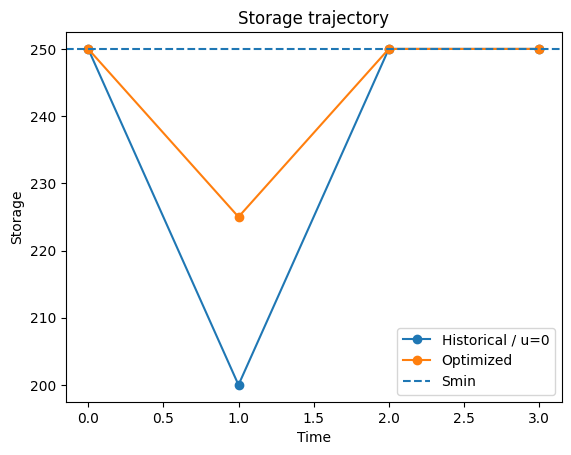

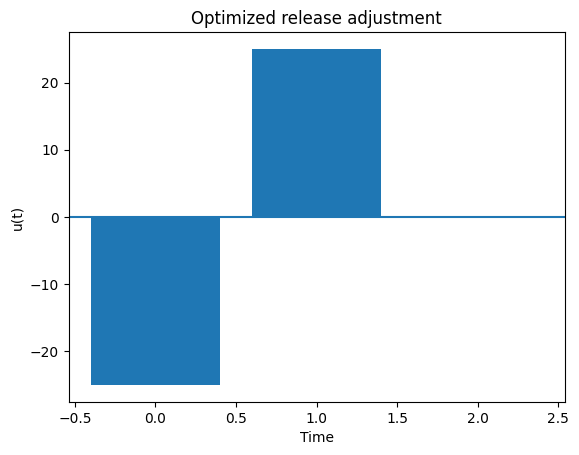

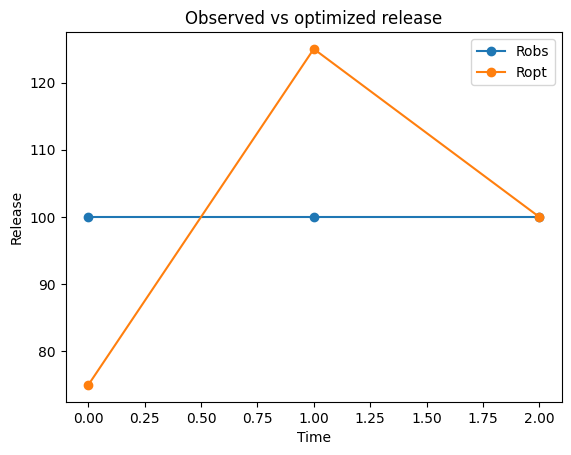

In [17]:
time_storage = np.arange(len(metrics["Sopt"]))
time_release = np.arange(T)

plt.figure()
plt.plot(time_storage, zero_metrics["Sopt"], marker="o", label="Historical / u=0")
plt.plot(time_storage, metrics["Sopt"], marker="o", label="Optimized")
plt.axhline(Smin, linestyle="--", label="Smin")
plt.xlabel("Time")
plt.ylabel("Storage")
plt.title("Storage trajectory")
plt.legend()
plt.show()

plt.figure()
plt.bar(time_release, uopt)
plt.axhline(0.0)
plt.xlabel("Time")
plt.ylabel("u(t)")
plt.title("Optimized release adjustment")
plt.show()

plt.figure()
plt.plot(time_release, R_obs, marker="o", label="Robs")
plt.plot(time_release, metrics["Ropt"], marker="o", label="Ropt")
plt.xlabel("Time")
plt.ylabel("Release")
plt.title("Observed vs optimized release")
plt.legend()
plt.show()

## 15. If it is still slow

Try these changes in the QAOA cell:

```python
result, qp = solve_with_qaoa(Q, reps=1, maxiter=10)
```

Or reduce shots in the sampler setup:

```python
run_options={"shots": 128, "seed": 123}
```

For this small toy problem, brute force is the best validation method because there are only:

\[
3^3=27
\]

valid release schedules.

A T4 GPU is useful mainly when the simulation is large enough for GPU acceleration to outweigh the overhead. For this 9-qubit example, CPU may still be faster.